# Quantum Coin Flip Game with Qiskit
Jerry Chen, NTU-IBM Quantum Hub.

## Learning Goals

In this notebook, we will:

1. Simulate a quantum coin toss.
2. Compare classical and quantum strategies.
3. Play a quantum coin game between two players.
4. See why a player with quantum technology can guarantee a win against a classical player.
5. See why the advantage disappears when both players have quantum technology.

---

## Game Rules

We use one qubit as a coin:

- $|0\rangle$ = **Heads**
- $|1\rangle$ = **Tails**

There are two players:

- **Player Q** wants the final result to be Heads.
- **Player B** wants the final result to be Tails.

The game has three moves:

1. Player Q acts.
2. Player B acts.
3. Player Q acts again.
4. The coin is measured.

The winner is determined by the measurement result.

## Part 0 — Import Qiskit

We use `AerSimulator` to simulate a quantum computer.

If Qiskit Aer is not installed, uncomment the installation line below and run it once.

In [1]:
# Uncomment this line if qiskit-aer is not installed
# !pip install qiskit qiskit-aer
# !pip install pylatexenc
# !pip install matplotlib

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()

print("Qiskit is ready!")

Qiskit is ready!


## Part 1 — A Quantum Coin Toss

A classical coin is either Heads or Tails.

A qubit can be prepared in the superposition state

$$
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

by applying a Hadamard gate:

$$
H|0\rangle = |+\rangle.
$$

When we measure $|+\rangle$, we obtain:

- Heads ($0$) with probability $50\%$
- Tails ($1$) with probability $50\%$

Run the following cell several times and compare the results.

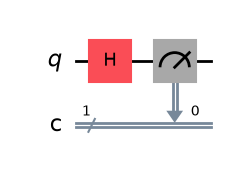

In [3]:
qc = QuantumCircuit(1, 1)

# Put the quantum coin into superposition
qc.h(0)

# Measure the coin
qc.measure(0, 0)

qc.draw("mpl")

In [4]:
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()
counts = result.get_counts()

print("Measurement results:", counts)
print(f"Heads: {counts.get('0', 0) / 1024:.1%}")
print(f"Tails: {counts.get('1', 0) / 1024:.1%}")

Measurement results: {'1': 512, '0': 512}
Heads: 50.0%
Tails: 50.0%


# Part 2 — When Both Players Are Classical

Now we remove quantum technology from **both** players first.

This means neither player can use the Hadamard gate.

Both players can only choose:

- $I$ — do nothing
- $X$ — flip the coin

The coin starts as Heads:

$$
|0\rangle.
$$

The game still has three moves:

1. Player A moves.
2. Player B moves.
3. Player A moves again.
4. The coin is measured.

Player A wants Heads.

Player B wants Tails.

Because both players can only use classical operations, the state is always either:

$$
|0\rangle
$$

or

$$
|1\rangle.
$$

There is no superposition during the game.

In [5]:
def classical_game(player_a_first="I", player_b_move="I", player_a_second="I", shots=1024):
    """
    Classical coin game using a quantum circuit.

    |0> = Heads
    |1> = Tails

    Both players can only choose:
    I = do nothing
    X = flip the coin
    """

    qc = QuantumCircuit(1, 1)

    # Player A's first move
    if player_a_first.upper() == "X":
        qc.x(0)
    elif player_a_first.upper() == "I":
        pass
    else:
        raise ValueError("Player A's first move must be I or X.")

    qc.barrier()

    # Player B's move
    if player_b_move.upper() == "X":
        qc.x(0)
    elif player_b_move.upper() == "I":
        pass
    else:
        raise ValueError("Player B's move must be I or X.")

    qc.barrier()

    # Player A's second move
    if player_a_second.upper() == "X":
        qc.x(0)
    elif player_a_second.upper() == "I":
        pass
    else:
        raise ValueError("Player A's second move must be I or X.")

    qc.measure(0, 0)

    compiled_qc = transpile(qc, simulator)
    result = simulator.run(compiled_qc, shots=shots).result()
    counts = result.get_counts()

    heads = counts.get("0", 0)
    tails = counts.get("1", 0)

    print(f"Player A first move:  {player_a_first.upper()}")
    print(f"Player B move:        {player_b_move.upper()}")
    print(f"Player A second move: {player_a_second.upper()}")
    print("Results:", counts)
    print(f"Heads / Player A win rate: {heads / shots:.1%}")
    print(f"Tails / Player B win rate: {tails / shots:.1%}")

    return qc, counts

## Example 1 — Nobody Flips the Coin

The moves are:

$$
I \rightarrow I \rightarrow I.
$$

The coin starts as Heads and stays Heads.

Player A first move:  I
Player B move:        I
Player A second move: I
Results: {'0': 1024}
Heads / Player A win rate: 100.0%
Tails / Player B win rate: 0.0%


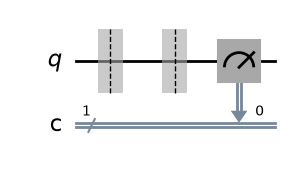

In [6]:
qc_classical_1, counts_classical_1 = classical_game("I", "I", "I")
qc_classical_1.draw("mpl")

## Example 2 — Player B Flips the Coin, But Player A Flips It Back

The moves are:

$$
I \rightarrow X \rightarrow X.
$$

The coin starts as Heads:

$$
|0\rangle.
$$

Player B flips it to Tails:

$$
X|0\rangle = |1\rangle.
$$

Player A flips it back to Heads:

$$
X|1\rangle = |0\rangle.
$$

So Player A wins.

Player A first move:  I
Player B move:        X
Player A second move: X
Results: {'0': 1024}
Heads / Player A win rate: 100.0%
Tails / Player B win rate: 0.0%


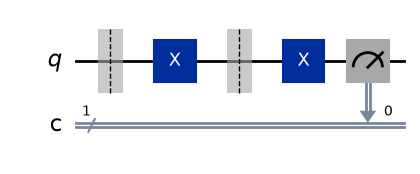

In [7]:
qc_classical_2, counts_classical_2 = classical_game("I", "X", "X")
qc_classical_2.draw("mpl")

## Example 3 — Player B Successfully Changes the Result

The moves are:

$$
I \rightarrow X \rightarrow I.
$$

The coin starts as Heads.

Player B flips it to Tails.

Player A does not flip it back.

So Player B wins.

Player A first move:  I
Player B move:        X
Player A second move: I
Results: {'1': 1024}
Heads / Player A win rate: 0.0%
Tails / Player B win rate: 100.0%


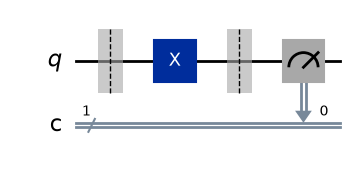

In [8]:
qc_classical_3, counts_classical_3 = classical_game("I", "X", "I")
qc_classical_3.draw("mpl")

## Random Classical Strategy

If both players choose randomly between $I$ and $X$, the final result should be close to 50/50.

This is similar to a fair classical game.

No player has a guaranteed advantage.

In [9]:
import random

def random_classical_game(rounds=1000):
    a_wins = 0
    b_wins = 0

    for _ in range(rounds):
        a1 = random.choice(["I", "X"])
        b = random.choice(["I", "X"])
        a2 = random.choice(["I", "X"])

        # Track the coin classically:
        # 0 = Heads, 1 = Tails
        coin = 0

        if a1 == "X":
            coin = 1 - coin
        if b == "X":
            coin = 1 - coin
        if a2 == "X":
            coin = 1 - coin

        if coin == 0:
            a_wins += 1
        else:
            b_wins += 1

    print(f"Total rounds: {rounds}")
    print(f"Player A wins: {a_wins} ({a_wins / rounds:.1%})")
    print(f"Player B wins: {b_wins} ({b_wins / rounds:.1%})")

random_classical_game(rounds=1000)

Total rounds: 1000
Player A wins: 523 (52.3%)
Player B wins: 477 (47.7%)


## Part 3 — The Classical Player's Choices

A classical player can make only two moves:

### Do nothing: $I$

The coin stays the same:

$$
I|0\rangle = |0\rangle, \qquad I|1\rangle = |1\rangle
$$

### Flip the coin: $X$

The coin is flipped:

$$
X|0\rangle = |1\rangle, \qquad X|1\rangle = |0\rangle
$$

Therefore, Player B can choose either:

- `I` — do nothing
- `X` — flip the coin

## Part 4 — The Quantum Strategy

Player Q has access to the Hadamard gate.

First, Player Q applies:

$$
H|0\rangle = |+\rangle.
$$

Now consider Player B's two classical choices.

If Player B does nothing:

$$
I|+\rangle = |+\rangle.
$$

If Player B flips the coin:

$$
X|+\rangle = |+\rangle.
$$

The key idea is that $|+\rangle$ is an eigenstate of the $X$ gate:

$$
X|+\rangle = +|+\rangle.
$$

Therefore, Player B cannot change the state, whether they choose $I$ or $X$.

Finally, Player Q applies another Hadamard gate:

$$
H|+\rangle = |0\rangle.
$$

The final result is always Heads.

**Player Q wins with 100% probability.**

In [10]:
def classical_vs_quantum(player_b_move="I", shots=1024):
    qc = QuantumCircuit(1, 1)

    # Player Q: hide the coin in the |+> state
    qc.h(0)
    qc.barrier()

    # Player B: classical move
    if player_b_move.upper() == "X":
        qc.x(0)
    elif player_b_move.upper() == "I":
        pass
    else:
        raise ValueError("Player B must choose 'I' or 'X'.")

    qc.barrier()

    # Player Q: recover |0>
    qc.h(0)

    # Measure
    qc.measure(0, 0)

    compiled_qc = transpile(qc, simulator)
    result = simulator.run(compiled_qc, shots=shots).result()
    counts = result.get_counts()

    heads = counts.get("0", 0)
    tails = counts.get("1", 0)

    print(f"Player B chose: {player_b_move.upper()}")
    print("Results:", counts)
    print(f"Player Q win rate: {heads / shots:.1%}")
    print(f"Player B win rate: {tails / shots:.1%}")

    return qc, counts

### Experiment A — Player B does nothing

Player B chooses $I$.

Player B chose: I
Results: {'0': 1024}
Player Q win rate: 100.0%
Player B win rate: 0.0%


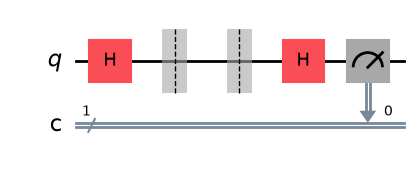

In [11]:
qc_I, counts_I = classical_vs_quantum("I")
qc_I.draw("mpl")

### Experiment B — Player B flips the coin

Player B chooses $X$.

Player B chose: X
Results: {'0': 1024}
Player Q win rate: 100.0%
Player B win rate: 0.0%


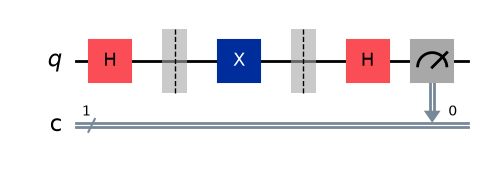

In [12]:
qc_X, counts_X = classical_vs_quantum("X")
qc_X.draw("mpl")

## Discussion

Did Player B's choice make any difference?

Why can Player Q guarantee a win?

The reason is:

$$
X|+\rangle = |+\rangle.
$$

After the first Hadamard gate, the "coin" is no longer simply Heads or Tails. The classical player's two available operations cannot distinguish the quantum strategy.

# Part 5 — What If Both Players Have Quantum Technology?

Now Player B is also allowed to use the Hadamard gate.

Suppose the moves are:

$$
|0\rangle
\xrightarrow{H}
|+\rangle
\xrightarrow{H}
|0\rangle
\xrightarrow{H}
|+\rangle.
$$

The final state is $|+\rangle$.

After measurement:

- Player Q wins about $50\%$ of the time.
- Player B wins about $50\%$ of the time.

The guaranteed quantum advantage disappears.

In [13]:
def quantum_vs_quantum(shots=1024):
    qc = QuantumCircuit(1, 1)

    # Player Q
    qc.h(0)
    qc.barrier()

    # Player B also has quantum technology
    qc.h(0)
    qc.barrier()

    # Player Q's final move
    qc.h(0)

    # Measure
    qc.measure(0, 0)

    compiled_qc = transpile(qc, simulator)
    result = simulator.run(compiled_qc, shots=shots).result()
    counts = result.get_counts()

    heads = counts.get("0", 0)
    tails = counts.get("1", 0)

    print("Results:", counts)
    print(f"Player Q win rate: {heads / shots:.1%}")
    print(f"Player B win rate: {tails / shots:.1%}")

    return qc, counts

Results: {'0': 508, '1': 516}
Player Q win rate: 49.6%
Player B win rate: 50.4%


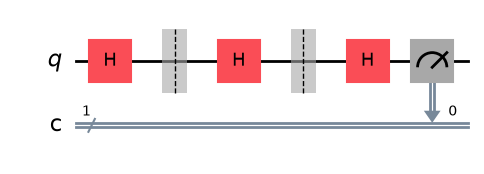

In [14]:
qc_qq, counts_qq = quantum_vs_quantum()
qc_qq.draw("mpl")

# Part 6 — Student Challenge

Try changing Player B's move.

Player B can choose:

- `I` — do nothing
- `X` — classical flip
- `H` — quantum Hadamard gate
- `other gates`

Can you find a strategy that defeats Player Q's original quantum strategy?

In [15]:
def play_game(player_b_move="I", shots=1024):
    qc = QuantumCircuit(1, 1)

    # Player Q's first move
    qc.h(0)
    qc.barrier()

    # Player B's move
    move = player_b_move.upper()

    if move == "I":
        pass
    elif move == "X":
        qc.x(0)
    elif move == "H":
        qc.h(0)
    else:
        raise ValueError("Choose I, X, or H.")

    qc.barrier()

    # Player Q's final move
    qc.h(0)

    qc.measure(0, 0)

    compiled_qc = transpile(qc, simulator)
    result = simulator.run(compiled_qc, shots=shots).result()
    counts = result.get_counts()

    q_wins = counts.get("0", 0)
    b_wins = counts.get("1", 0)

    print(f"Player B's move: {move}")
    print(f"Player Q win rate: {q_wins / shots:.1%}")
    print(f"Player B win rate: {b_wins / shots:.1%}")

    return qc, counts

Player B's move: Z
Player Q win rate: 0.0%
Player B win rate: 100.0%


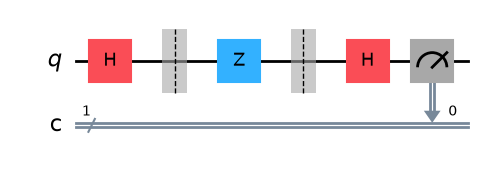

In [16]:
# Change this move and run the cell again:
player_b_move = "H"

challenge_circuit, challenge_counts = play_game(player_b_move)
challenge_circuit.draw("mpl")

## Comparison with the Quantum Strategy

In the classical-only version:

- The coin is always either Heads or Tails.
- The allowed operations are only $I$ and $X$.
- There is no superposition.
- Neither player can hide the coin in the $|+\rangle$ state.
- Therefore, no player has the special quantum advantage.

In the quantum version, Player Q used:

$$
H|0\rangle = |+\rangle.
$$

Because

$$
X|+\rangle = |+\rangle,
$$

the classical player's flip could not change the state.

That is the source of the quantum advantage.

So the key comparison is:

| Situation | Allowed moves | Result |
|---|---|---|
| Both players classical | $I$, $X$ | No quantum advantage |
| Player Q quantum, Player B classical | $H$, $I$, $X$ | Player Q can guarantee Heads |
| Both players quantum | $H$, $I$, $X$ | Advantage can disappear |

# Key Takeaway

This game demonstrates an important idea:

> A quantum strategy can create a powerful advantage when only one player has access to quantum operations.

Against a classical player restricted to $I$ and $X$, Player Q can use

$$
H \rightarrow \text{opponent's move} \rightarrow H
$$

to guarantee a win.

However, once both players can manipulate quantum states, the original guaranteed advantage disappears.

The broader lesson is not simply that "quantum always wins." Instead:

> **Quantum advantage depends on what operations and resources each player is allowed to use.**